# 07_01.K-Nearest Neighbors(예측)

## 1.기본 package 설정

In [ ]:
# 그래프에서 한글 폰트 인식하기
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

#  *** 런타임 다시 시작

In [ ]:
## 1.기본
import numpy as np  # numpy 패키지 가져오기
import matplotlib.pyplot as plt # 시각화 패키지 가져오기
import seaborn as sns # 시각화

## 2.데이터 가져오기
import pandas as pd # csv -> dataframe으로 전환

## 3.데이터 전처리
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder

# 4. 훈련/검증용 데이터 분리
from sklearn.model_selection import train_test_split

## 5.모델구축
from sklearn.neighbors import KNeighborsRegressor # K-최근접 이웃(예측)
# from sklearn.neighbors import KNeighborsClassifier # K-최근접 이웃(분류)

## 6.모델검정
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 7.최적화
from sklearn.model_selection import GridSearchCV # 하이퍼파라미터 튜닝

## 2.데이터 불러오기

### 2.1 구글 드라이브와 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2.2 데이터 프레임으로 저장
- 원본데이터(csv)를 dataframe 형태로 가져오기(pandas)

In [ ]:
housing_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/주택가격.csv', encoding="cp949")
housing_df.head()

,id,가격,연면적,품질,상태,건축년도,리모델링년도,지하면적,차고면적,면적_1층,면적_2층,주거유형,판매유형,판매조건
0,1,208500,8450,7,5,2003,2003,856,548,856,854,1,1,1
1,2,181500,9600,6,8,1976,1976,1262,460,1262,0,1,1,1
2,3,223500,11250,7,5,2001,2002,920,608,920,866,1,1,1
3,4,140000,9550,7,5,1915,1970,756,642,961,756,1,1,2
4,5,250000,14260,8,5,2000,2000,1145,836,1145,1053,1,1,1


### 2.3 자료구조 살펴보기

In [ ]:
housing_df.shape

In [ ]:
housing_df.info()

In [ ]:
housing_df.columns

## 3.데이터 전처리

### 3.1 필요없는 변수 제거

In [ ]:
housing_df = housing_df.drop (['id'], axis=1)
housing_df.head()

,가격,연면적,품질,상태,건축년도,리모델링년도,지하면적,차고면적,면적_1층,면적_2층,주거유형,판매유형,판매조건
0,208500,8450,7,5,2003,2003,856,548,856,854,1,1,1
1,181500,9600,6,8,1976,1976,1262,460,1262,0,1,1,1
2,223500,11250,7,5,2001,2002,920,608,920,866,1,1,1
3,140000,9550,7,5,1915,1970,756,642,961,756,1,1,2
4,250000,14260,8,5,2000,2000,1145,836,1145,1053,1,1,1


### 3.2 범주형 변수 처리
- 가변수 처리시 문자로 처리를 해야 변수명 구분이 쉬움

In [ ]:
housing_df['주거유형'] = housing_df['주거유형'].replace ([1,2,3,4,5], ['단독주택','2가구변경','듀플렉스','타운젠트바깥쪽','타운젠트안쪽'])
housing_df['판매유형'] = housing_df['판매유형'].replace ([1,2], ['보증증서','법원관리증서'])
housing_df['판매조건'] = housing_df['판매조건'].replace ([1,2], ['정상판매','압류및공매도'])
housing_df.head()

,가격,연면적,품질,상태,건축년도,리모델링년도,지하면적,차고면적,면적_1층,면적_2층,주거유형,판매유형,판매조건
0,208500,8450,7,5,2003,2003,856,548,856,854,단독주택,보증증서,정상판매
1,181500,9600,6,8,1976,1976,1262,460,1262,0,단독주택,보증증서,정상판매
2,223500,11250,7,5,2001,2002,920,608,920,866,단독주택,보증증서,정상판매
3,140000,9550,7,5,1915,1970,756,642,961,756,단독주택,보증증서,압류및공매도
4,250000,14260,8,5,2000,2000,1145,836,1145,1053,단독주택,보증증서,정상판매


## 4.데이터 탐색

### 4.1 EDA 데이터 탐색

In [ ]:
# 수치형 변수
housing_df.describe().round(2).T

In [ ]:
# 범주형 변수
# lecture_df.columns
categorical_features=['주거유형', '판매유형', '판매조건']

for col in categorical_features:
    cat = housing_df[col].value_counts()
    print(cat)

### 4.2 그래프 그리기

In [ ]:
# 한글 폰트 인식
plt.rc('font', family='NanumBarunGothic')

In [ ]:
# 수치형 변수
g = sns.pairplot(housing_df)

In [ ]:
# 변수별 선형회귀직선
variables = ['연면적', '품질', '상태', '건축년도', '리모델링년도', '지하면적',
             '차고면적', '면적_1층', '면적_2층']

for var in variables:
    plt.figure()
    sns.regplot(x = var, y = '가격', data = housing_df).set(title=f'{var} and 가격에 따른 회귀직선');

In [ ]:
# 범주형 변수
for col in categorical_features:
    sns.countplot(x=col, data = housing_df)
    plt.show()

### 4.3 base accuracy


In [ ]:
# base accuracy
housing_df['가격'].mean()

## 5.훈련/테스트용 데이터 분할


### 5.1 data와 target으로 분리
- data: X, target: y 로 분리

- X 추출


In [ ]:
X = housing_df.drop (['가격'], axis=1)
X.head()

,연면적,품질,상태,건축년도,리모델링년도,지하면적,차고면적,면적_1층,면적_2층,주거유형,판매유형,판매조건
0,8450,7,5,2003,2003,856,548,856,854,단독주택,보증증서,정상판매
1,9600,6,8,1976,1976,1262,460,1262,0,단독주택,보증증서,정상판매
2,11250,7,5,2001,2002,920,608,920,866,단독주택,보증증서,정상판매
3,9550,7,5,1915,1970,756,642,961,756,단독주택,보증증서,압류및공매도
4,14260,8,5,2000,2000,1145,836,1145,1053,단독주택,보증증서,정상판매


- target(y) 추출
- y 값을 series에서 배열로 변환

In [ ]:
y = housing_df['가격']
y.head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: 가격, dtype: int64

In [ ]:
# 선형모델의 y 값 표준화
y = StandardScaler().fit_transform(y[:, np.newaxis]).flatten()
y

<ipython-input-8-86a83c11e717>:2: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = StandardScaler().fit_transform(y[:, np.newaxis]).flatten()


array([ 0.87174655,  0.3601134 ,  1.15598719, ...,  1.97081036,
       -0.38601829, -0.28416539])

### 5.2 훈련용 및 테스트용 데이터 분할
- test_size: 검증데이터 30%
- random_state : random seed 번호 = 1
- stratify : y(클래스)의 비율에 따라 분할(분류모형일때 사용)

In [ ]:
# \ 이후에 space 없어야 함
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.3,
                                                    random_state = 1)

In [ ]:
X_train.info()

In [ ]:
y_train.info()

In [ ]:
X_test.info()

In [ ]:
y_test.info()

## 6.pipeline으로 데이터 전처리
https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html
- R에서 recipe
- 범주형 변수: OneHotEncoder
- 수치형 변수:
- 선형모델은 StandardScaler 로 표준화
- tree형 모델은 데이터 원형 사용

### 6.1 preprocess 세팅

In [ ]:
# pipeline으로 세팅
# 수치형 변수(y는 제외)
numeric_features = ['연면적', '품질', '상태', '건축년도', '리모델링년도',
                    '지하면적', '차고면적', '면적_1층', '면적_2층']

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')), # 누락된 값은 중앙값으로 처리
        ('scaler', StandardScaler())
    ]
)

# 범주형 변수(y는 제외)
categorical_features=['주거유형', '판매유형', '판매조건']

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant',
                                  fill_value='missing')),  # 누락된 값은 missing으로 상수 처리
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# preprocessor로 데이터 변환 세팅
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['연면적', '품질', '상태', '건축년도', '리모델링년도', '지하면적',
                                  '차고면적', '면적_1층', '면적_2층']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['주거유형', '판매유형', '판매조건'])])

### 6.2 데이터 전처리 결과 확인
- https://www.kaggle.com/code/thomasswain/titanic-classifier

In [ ]:
pd.DataFrame(preprocessor.fit_transform(X_train)).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,-0.596577,-0.709282,1.204375,0.067463,-0.614537,-0.610066,0.965758,-1.005785,-0.789563,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.494475,-1.529824,-0.588082,-0.106458,-0.860567,-0.093881,-0.052596,-0.425396,-0.789563,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,-0.075530,-0.709282,-0.588082,0.206599,-0.417714,-0.265943,-2.343893,-0.618859,1.430503,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-2.147846,-0.709282,-0.588082,0.067463,-0.614537,-0.981073,-0.010165,-1.422939,0.875486,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,-0.894487,-0.709282,-1.484311,-1.115198,-1.598655,-0.265943,-1.070950,-0.618859,0.320470,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


## 7.모델만들기 (모델 설정)
- R에서 workflow
- 예측모델: 000_reg
- 분류모델: 000_clf

### 7.1 pipeline으로 모델 연결

In [ ]:
knn_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("knn_reg", KNeighborsRegressor())
    ]
)

### 7.2 하이퍼파라미터 세팅
- 그리드 서치를 사용한 머신 러닝 모델 세부 튜닝
- 기계학습 모델의 성능을 결정하는 하이퍼 파라미터 튜닝

In [ ]:
knn_pipe.get_params().keys()

dict_keys(['memory', 'steps', 'verbose', 'preprocessor', 'knn_reg', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__cat', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__scaler', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__num__imputer__verbose', 'preprocessor__num__scaler__copy', 'preprocessor__num__scaler__with_mean', 'preprocessor__num__scaler__with_std', 'preprocessor__cat__memory', 'preprocessor__cat__steps', 'preprocessor__cat__verbose', 'preprocessor__cat__impu

In [ ]:
knn_grid = {
    'knn_reg__n_neighbors' : [3, 5, 7, 9],
    'knn_reg__weights' : ['uniform','distance'],
    'knn_reg__metric' : ['minkowski','euclidean','manhattan']
}

knn_grid

{'knn_reg__n_neighbors': [3, 5, 7, 9],
 'knn_reg__weights': ['uniform', 'distance'],
 'knn_reg__metric': ['minkowski', 'euclidean', 'manhattan']}

### 7.3 하이퍼파라미터 그리드 만들기

In [ ]:
knn_gs = GridSearchCV(estimator = knn_pipe,
                     param_grid = knn_grid,
                     scoring='r2',             # mse, r2
                     cv = 10,
                     n_jobs = -1,
                     verbose = 10,              # 프로세스 진행사항 확인
                     return_train_score = True) # 훈련결과 저장

## 8.모델 훈련(모델 학습)
- machine learning

### 8.1 모델 훈련하기(learning)

In [ ]:
knn_gs.fit(X_train, y_train)

Fitting 10 folds for each of 24 candidates, totalling 240 fits


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['연면적',
                                                                          '품질',
                                                                          '상태',
                                                                          '건축년도',
                                                                          '리모델링년도',
                                                                          '지하면적',
                                                                          '차고면적',
                                                                          '면적_1층',
                                                                          '면적_2층']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='missing',
                                                                                                        strategy='constant')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['주거유형',
                                                                          '판매유형',
                                                                          '판매조건'])])),
                                       ('knn_reg', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'knn_reg__metric': ['minkowski', 'euclidean',
                                             'manhattan'],
                         'knn_reg__n_neighbors': [3, 5, 7, 9],
                         'knn_reg__weights': ['uniform', 'distance']},
             return_train_score=True, scoring='r2', verbose=10)

### 8.2 검증 곡선으로 Tuning 결과 확인
- 결과 표로 정리: https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_stats.html#sphx-glr-auto-examples-model-selection-plot-grid-search-stats-py
- 그래프로 정리: https://stackoverflow.com/questions/37161563/how-to-graph-grid-scores-from-gridsearchcv

In [ ]:
# 결과확인
knn_gs.cv_results_

{'mean_fit_time': array([0.01645887, 0.01901488, 0.01500447, 0.01515026, 0.0138943 ,
        0.01619041, 0.01548572, 0.014046  , 0.01677465, 0.01522837,
        0.01619899, 0.01557605, 0.01473014, 0.0174978 , 0.01485767,
        0.01510618, 0.01398194, 0.018695  , 0.02599535, 0.02901874,
        0.02766507, 0.02494981, 0.02371354, 0.02548759]),
 'std_fit_time': array([0.0020248 , 0.00614065, 0.00101924, 0.00176509, 0.00079855,
        0.00486488, 0.00254642, 0.0007707 , 0.00418788, 0.00173252,
        0.0046125 , 0.00368348, 0.00101115, 0.00597739, 0.00151676,
        0.00249665, 0.00071464, 0.00553565, 0.00236254, 0.00515011,
        0.00401564, 0.003003  , 0.00617792, 0.00649443]),
 'mean_score_time': array([0.01501369, 0.00818002, 0.00813296, 0.00869288, 0.00798476,
        0.00857804, 0.00787489, 0.00878656, 0.0095499 , 0.00831306,
        0.00755246, 0.00801911, 0.00848579, 0.00775256, 0.00791113,
        0.00903471, 0.01089358, 0.01256216, 0.01892178, 0.01902416,
        0.019049

In [ ]:
# 분석결과를 표로 정리
results_df = pd.DataFrame(knn_gs.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
manhattan_7_distance,"{'knn_reg__metric': 'manhattan', 'knn_reg__n_n...",1,0.844553,0.025860
manhattan_9_distance,"{'knn_reg__metric': 'manhattan', 'knn_reg__n_n...",2,0.843849,0.025920
manhattan_5_distance,"{'knn_reg__metric': 'manhattan', 'knn_reg__n_n...",3,0.841461,0.027478
euclidean_9_distance,"{'knn_reg__metric': 'euclidean', 'knn_reg__n_n...",4,0.840485,0.030034
minkowski_9_distance,"{'knn_reg__metric': 'minkowski', 'knn_reg__n_n...",4,0.840485,0.030034
minkowski_7_distance,"{'knn_reg__metric': 'minkowski', 'knn_reg__n_n...",6,0.838783,0.030828
euclidean_7_distance,"{'knn_reg__metric': 'euclidean', 'knn_reg__n_n...",6,0.838783,0.030828
manhattan_7_uniform,"{'knn_reg__metric': 'manhattan', 'knn_reg__n_n...",8,0.838688,0.026908
manhattan_9_uniform,"{'knn_reg__metric': 'manhattan', 'knn_reg__n_n...",9,0.837959,0.027183


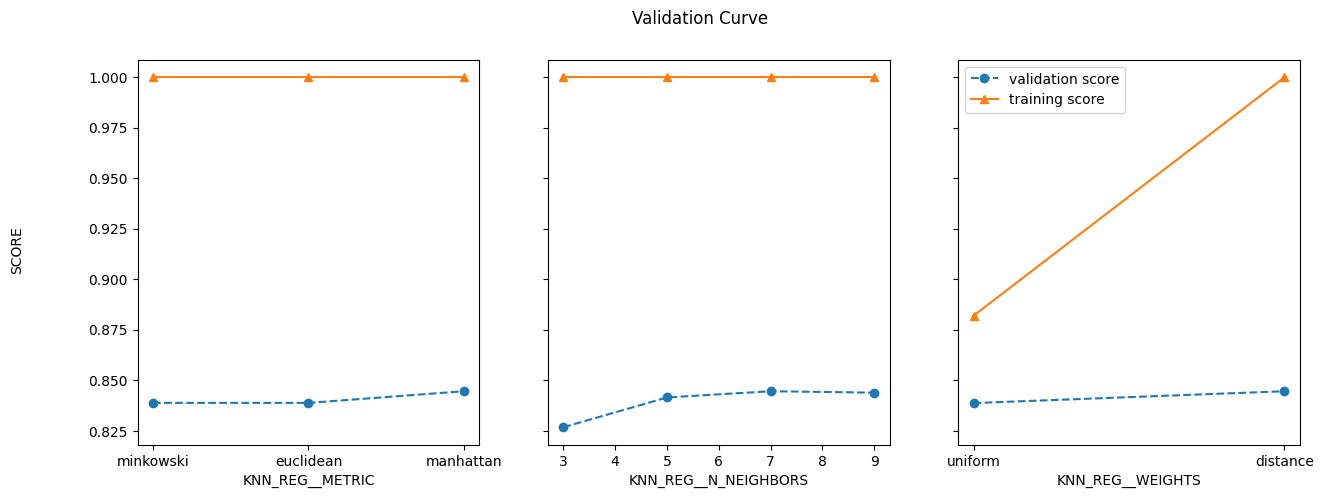

In [ ]:
# 튜닝결과 그래프
# 파라미터값이 ( , )로 되어 있어서 그래프로 구현 못함

results = knn_gs.cv_results_
means_test = results['mean_test_score']
means_train = results['mean_train_score']

masks = []
masks_names = list(knn_gs.best_params_.keys())
for p_k, p_v in knn_gs.best_params_.items():
    masks.append(list(results['param_'+p_k].data==p_v))

params = knn_gs.param_grid

fig, ax = plt.subplots(1,len(params),
                       sharex='none',
                       sharey='all',
                       figsize=(15,5))
fig.suptitle('Validation Curve')
fig.text(0.04, 0.5, 'SCORE', va='center', rotation='vertical')

for i, p in enumerate(masks_names):
    m = np.stack(masks[:i] + masks[i+1:])
    best_parms_mask = m.all(axis=0)
    best_index = np.where(best_parms_mask)[0]
    x = np.array(params[p])
    y_1 = np.array(means_test[best_index])
    y_2 = np.array(means_train[best_index])
    ax[i].errorbar(x, y_1, linestyle='--', marker='o', label='validation score')
    ax[i].errorbar(x, y_2, linestyle='-', marker='^',label='training score' )
    ax[i].set_xlabel(p.upper())

plt.legend()
plt.show()

### 8.3 best 모델 설정

In [ ]:
# best 모델 파라미터 확인
print(knn_gs.best_score_)
print(knn_gs.best_params_)

0.8445530395979294
{'knn_reg__metric': 'manhattan', 'knn_reg__n_neighbors': 7, 'knn_reg__weights': 'distance'}


In [ ]:
# best 모델 파라미터를 최종모델로 훈련
best_reg = knn_gs.best_estimator_
best_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['연면적', '품질', '상태', '건축년도',
                                                   '리모델링년도', '지하면적', '차고면적',
                                                   '면적_1층', '면적_2층']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['주거유형', '판매유형', '판매조건'])])),
                ('knn_reg',
                 KNeighborsRegressor(metric='manhattan', n_neighbors=7,
                                     weights='distance'))])

In [ ]:
print(best_reg['knn_reg'])

KNeighborsRegressor(metric='manhattan', n_neighbors=7, weights='distance')


### 8.4 중요변수확인

In [ ]:
# 중요도 점수 계산
# KNN은 점수 계산 안됨


In [ ]:
# 그래프 그리기


## 9.모델 test 및 검정

### 9.1 검증용 데이터로 예측
- predict (class로 표시)
- predict_proba (확률값으로 표시): 분류모델에서 사용

In [ ]:
y_pred = best_reg.predict(X_test) # knn_reg -> knn_pipe
y_pred

array([ 1.05713466, -1.06969561, -1.22582614,  0.65797892,  0.16638073,
        0.9478437 , -0.58363801, -0.85348244, -0.5068846 , -0.19837613,
       -0.24765204, -0.19837613, -0.42947266,  0.40835876, -0.58221177,
       -0.39119357, -0.27433245, -0.36703722, -0.34050311,  0.01947976,
       -1.25084077,  0.21059648, -0.19837613,  1.03073424,  1.42880471,
        1.12802046, -0.12587922, -0.84344699,  0.70570634, -1.25147461,
       -1.53869414, -0.52860005, -0.48315613,  0.6486811 ,  1.62330446,
        1.04572853,  2.1673561 ,  0.52620289,  0.76404269,  0.97504854,
       -0.31058966,  0.00712481,  0.9060128 , -0.67200191,  1.99506582,
       -1.34278835, -0.86715198, -1.25520497,  0.69323741, -0.41729934,
        0.61091686, -0.57644258,  0.55999913,  0.38389975,  0.4140691 ,
        0.3235836 ,  1.22124454, -0.30560529, -0.81216257, -1.5665075 ,
       -0.18682321,  0.69656695, -0.40630199,  0.33690554,  1.73902827,
       -0.34690902, -0.49329823, -0.02672649, -0.49970068, -0.47

### 9.2 실제값과 예측값 확인

In [ ]:
output = pd.DataFrame({'Actual': y_test.squeeze(), 'Predicted': y_pred.squeeze()})
output

,Actual,Predicted
0,1.411804,1.057135
1,-1.023570,-1.069696
2,-1.705369,-1.225826
3,1.487601,0.657979
4,0.316530,0.166381
...,...,...
349,1.203361,0.872350
350,1.960938,1.310944
351,0.578031,0.442234
352,1.080190,1.479988


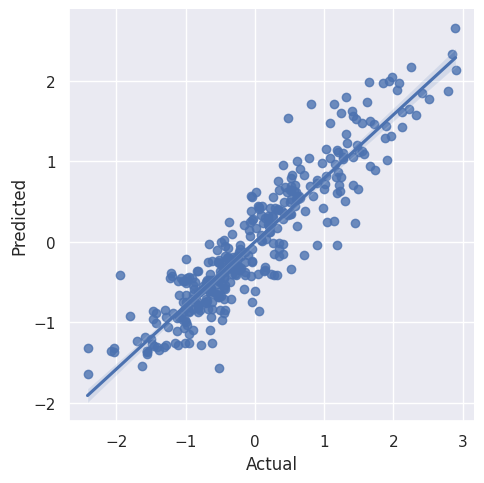

In [ ]:
sns.lmplot(x ='Actual', y ='Predicted', data = output)

### 9.3 모델 검정

In [ ]:
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
print('MSE: %.3f' % mean_squared_error(y_test,y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test,y_pred))
print('RMSE: %.3f' % np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2: %.3f' % r2_score(y_test,y_pred))

MSE: 428212511.986
MAE: 15507.288
RMSE: 20693.296
R2: 0.848
